In [ ]:
pip install langgraph langchain-google-genai geopy requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.3 MB/s eta 0:00:00


In [ ]:
import os



In [ ]:
api_key = "........."

In [ ]:
from typing import Annotated,Sequence, TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages  # helper function to add messages to the state


class AgentState(TypedDict):
    """The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    number_of_steps: int


In [ ]:
from langchain_core.tools import tool
from geopy.geocoders import Nominatim
from pydantic import BaseModel, Field
import requests

geolocator = Nominatim(user_agent="weather-app")

class SearchInput(BaseModel):
    location:str = Field(description="The city and state, e.g., San Francisco")
    date:str = Field(description="the forecasting date for when to get the weather format (yyyy-mm-dd)")

@tool("get_weather_forecast", args_schema=SearchInput, return_direct=True)
def get_weather_forecast(location: str, date: str):
    """Retrieves the weather using Open-Meteo API.

    Takes a given location (city) and a date (yyyy-mm-dd).

    Returns:
        A dict with the time and temperature for each hour.
    """
    # Note that Colab may experience rate limiting on this service. If this
    # happens, use a machine to which you have exclusive access.
    location = geolocator.geocode(location)
    if location:
        try:
            response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={location.latitude}&longitude={location.longitude}&hourly=temperature_2m&start_date={date}&end_date={date}")
            data = response.json()
            return dict(zip(data["hourly"]["time"], data["hourly"]["temperature_2m"]))
        except Exception as e:
            return {"error": str(e)}
    else:
        return {"error": "Location not found"}

tools = [get_weather_forecast]


In [ ]:
from datetime import datetime
from langchain_google_genai import ChatGoogleGenerativeAI

# Create LLM class
llm = ChatGoogleGenerativeAI(
    model= "gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)

# Bind tools to the model
model = llm.bind_tools([get_weather_forecast])

# Test the model with tools
res=model.invoke(f"What is the weather in Berlin on {datetime.today()}?")

print(res)


content=[] additional_kwargs={'function_call': {'name': 'get_weather_forecast', 'arguments': '{"location": "Berlin", "date": "2026-03-23"}'}, '__gemini_function_call_thought_signatures__': {'5f5e71e4-ac3c-496e-8b8c-332dc483261b': 'EpcDCpQDAb4+9vu2qAQkFWCaffrJrBGItFMf18BYEgZbSkEkRen7IwneCvKVf5EIPnGWLQjs1oR22iFR3WOMqQc8Bh4Jh5m5wCRIVOBt6+SZGPz/nIYC0xERMgIeZ7wCwqqT/XvTy3/BlkTPeq7nXWCEEn75Dr0rR3TedQBMRJ/ABMUrDskC4l4BXFKUG7/ntNUEo7gsYJFjW7UJ/FoaEt5z+nHqqJxGDNcR2eLBW+2SHHORzzchAj6hYK6MGFh5vkPOWth7BD/fQRsQU4SrSNOuF9tGU3l4/GuZe7Fpvcd0hysa1Im52ZUG90iYj48vCAjNPuVa1y3UBxWdp3GQDwp97nKr1Bqtodd/uGF46QpnKo9n4APRw0GNttk4yZ5APsEdE4evltpP8PY94jgnJZFq5E5dzy85MNW9zawe3Uj3hDInSicYD2oAt89ljF4a4znrrHVlJaEtkzIccqjb1MspLTtvoYBCPfETokTNAPK9g0yoj+h5E/aSXX38FA+T5psTMaR+w+5ahDz5zPFXKTyK3sWjRHHjtuU='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d1bf7-ae37-7622-8aeb-85a647101646-0' tool_calls=[{'name': 'get

In [ ]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableConfig

tools_by_name = {tool.name: tool for tool in tools}

# Define our tool node
def call_tool(state: AgentState):
    outputs = []
    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool by name
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=tool_result,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # Invoke the model with the system prompt and the messages
    response = model.invoke(state["messages"], config)
    # This returns a list, which combines with the existing messages state
    # using the add_messages reducer.
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    # If the last message is not a tool call, then finish
    if not messages[-1].tool_calls:
        return "end"
    # default to continue
    return "continue"


In [ ]:
from langgraph.graph import StateGraph, END

# Define a new graph with our state
workflow = StateGraph(AgentState)

# 1. Add the nodes
workflow.add_node("llm", call_model)
workflow.add_node("tools",  call_tool)
# 2. Set the entrypoint as `agent`, this is the first node called
workflow.set_entry_point("llm")
# 3. Add a conditional edge after the `llm` node is called.
workflow.add_conditional_edges(
    # Edge is used after the `llm` node is called.
    "llm",
    # The function that will determine which node is called next.
    should_continue,
    # Mapping for where to go next, keys are strings from the function return,
    # and the values are other nodes.
    # END is a special node marking that the graph is finish.
    {
        # If `tools`, then we call the tool node.
        "continue": "tools",
        # Otherwise we finish.
        "end": END,
    },
)
# 4. Add a normal edge after `tools` is called, `llm` node is called next.
workflow.add_edge("tools", "llm")

# Now we can compile and visualize our graph
graph = workflow.compile()


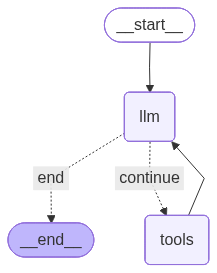

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
from datetime import datetime
# Create our initial message dictionary
inputs = {"messages": [("user", f"What is the weather in Berlin on {datetime.today()}?")]}

# call our graph with streaming to see the steps
for state in graph.stream(inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()


================================ Human Message =================================

What is the weather in Berlin on 2026-03-23 18:32:45.624675?
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather_forecast (24722bfb-dd2a-45ee-b808-f3c344514cc0)
 Call ID: 24722bfb-dd2a-45ee-b808-f3c344514cc0
  Args:
    location: Berlin
    date: 2026-03-23
================================= Tool Message =================================
Name: get_weather_forecast

{'2026-03-23T00:00': 7.0, '2026-03-23T01:00': 6.6, '2026-03-23T02:00': 6.1, '2026-03-23T03:00': 5.2, '2026-03-23T04:00': 4.8, '2026-03-23T05:00': 4.4, '2026-03-23T06:00': 3.0, '2026-03-23T07:00': 4.7, '2026-03-23T08:00': 7.3, '2026-03-23T09:00': 10.2, '2026-03-23T10:00': 12.5, '2026-03-23T11:00': 14.2, '2026-03-23T12:00': 15.3, '2026-03-23T13:00': 15.4, '2026-03-23T14:00': 15.7, '2026-03-23T15:00': 15.3, '2026-03-23T16:00': 15.3, '2026-03-23T17:00': 14.6, '2026-03-23T18:00': 13.7, '2026-

In [ ]:
state["messages"].append(("user", "Would it be warmer in Munich?"))

for state in graph.stream(state, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()
